# Week 11. 와인 분류 대시보드와 모델 서비스 흐름

## 제출자 정보

| 항목 | 내용 |
|---|---|
| 이름 | 이성민 |
| 학과 | 소프트웨어융합과 |
| 학년 | 2학년 |
| 학번 | 2151050 |

## 학습 목표

이번 주차는 머신러닝 모델을 단순히 학습하는 데서 끝내지 않고, 사용자가 확인할 수 있는 대시보드 형태로 연결하는 흐름을 다룹니다.

핵심 흐름은 다음과 같습니다.

1. 입력 데이터 준비
2. 분류 기준 또는 모델 만들기
3. 예측 함수 작성
4. 피처 중요도와 예측 결과를 표/그래프로 설명
5. FastAPI 또는 Gradio에 붙일 수 있는 서비스 함수 형태로 정리

실제 서비스에서는 scikit-learn 모델을 사용할 수 있지만, 이 노트북은 어디서나 실행되도록 작은 로컬 데이터와 규칙 기반 모델로 구조를 설명합니다.

## 1. 와인 데이터 만들기

와인 분류 데이터는 알코올 도수, 색 농도, 플라보노이드 같은 수치형 특성을 사용해 품종을 분류하는 예제로 자주 사용됩니다.

아래 데이터는 실제 데이터셋을 외부에서 내려받지 않고, 대시보드 흐름을 설명하기 위해 만든 작은 샘플입니다.
각 행은 와인 한 병의 특성과 정답 클래스를 의미합니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

wine = pd.DataFrame([
    {"wine_id": "W001", "alcohol": 13.2, "color_intensity": 5.1, "flavanoids": 3.0, "class_name": "class_0"},
    {"wine_id": "W002", "alcohol": 12.3, "color_intensity": 3.2, "flavanoids": 2.1, "class_name": "class_1"},
    {"wine_id": "W003", "alcohol": 14.1, "color_intensity": 7.2, "flavanoids": 1.3, "class_name": "class_2"},
    {"wine_id": "W004", "alcohol": 13.8, "color_intensity": 6.8, "flavanoids": 1.1, "class_name": "class_2"},
    {"wine_id": "W005", "alcohol": 12.8, "color_intensity": 4.8, "flavanoids": 2.9, "class_name": "class_0"},
    {"wine_id": "W006", "alcohol": 11.9, "color_intensity": 3.8, "flavanoids": 1.9, "class_name": "class_1"},
])

assert wine.shape == (6, 5)
assert wine[["alcohol", "color_intensity", "flavanoids"]].notna().all().all()
wine

,wine_id,alcohol,color_intensity,flavanoids,class_name
0,W001,13.2,5.1,3.0,class_0
1,W002,12.3,3.2,2.1,class_1
2,W003,14.1,7.2,1.3,class_2
3,W004,13.8,6.8,1.1,class_2
4,W005,12.8,4.8,2.9,class_0
5,W006,11.9,3.8,1.9,class_1


## 2. 대시보드용 요약 테이블 만들기

대시보드는 원본 데이터를 그대로 보여주는 것보다, 사용자가 빠르게 이해할 수 있는 요약 지표를 함께 제공해야 합니다.

여기서는 클래스별 개수, 평균 알코올 도수, 평균 색 농도, 평균 플라보노이드를 계산합니다.
이 요약표는 `/data` API 응답이나 Gradio의 DataFrame 컴포넌트에 그대로 연결할 수 있습니다.

In [2]:
class_summary = (
    wine.groupby("class_name", as_index=False)
    .agg(
        count=("wine_id", "count"),
        avg_alcohol=("alcohol", "mean"),
        avg_color=("color_intensity", "mean"),
        avg_flavanoids=("flavanoids", "mean"),
    )
    .round(2)
)

assert class_summary["count"].sum() == len(wine)
class_summary

,class_name,count,avg_alcohol,avg_color,avg_flavanoids
0,class_0,2,13.00,4.95,2.95
1,class_1,2,12.10,3.50,2.00
2,class_2,2,13.95,7.00,1.20


## 3. 예측 함수 만들기

실제 모델은 학습 데이터로부터 복잡한 경계를 학습하지만, 서비스 구조를 이해하려면 먼저 입력과 출력이 분명한 함수가 필요합니다.

아래 함수는 색 농도와 플라보노이드 값을 기준으로 품종을 분류합니다.
중요한 점은 함수가 다음 조건을 지킨다는 것입니다.

- 입력값이 잘못되면 오류를 명확히 발생시킨다.
- 출력은 API 응답으로 쓰기 쉬운 딕셔너리 형태로 반환한다.
- 예측 근거도 함께 반환해 사용자가 결과를 해석할 수 있게 한다.

In [3]:
def predict_wine_class(alcohol: float, color_intensity: float, flavanoids: float) -> dict:
    if alcohol <= 0 or color_intensity <= 0 or flavanoids <= 0:
        raise ValueError("모든 측정값은 0보다 커야 합니다.")

    if color_intensity >= 6.0:
        label = "class_2"
        reason = "색 농도가 높아 class_2로 분류했습니다."
    elif flavanoids >= 2.5:
        label = "class_0"
        reason = "플라보노이드가 높아 class_0로 분류했습니다."
    else:
        label = "class_1"
        reason = "색 농도와 플라보노이드가 낮아 class_1로 분류했습니다."

    return {
        "input": {
            "alcohol": alcohol,
            "color_intensity": color_intensity,
            "flavanoids": flavanoids,
        },
        "prediction": label,
        "reason": reason,
    }

sample_prediction = predict_wine_class(13.0, 5.0, 3.1)
assert sample_prediction["prediction"] == "class_0"
sample_prediction

{'input': {'alcohol': 13.0, 'color_intensity': 5.0, 'flavanoids': 3.1},
 'prediction': 'class_0',
 'reason': '플라보노이드가 높아 class_0로 분류했습니다.'}

## 4. 피처 중요도 시각화

사용자는 모델이 어떤 변수를 중요하게 보는지 알고 싶어 합니다.
실제 RandomForest에서는 `feature_importances_` 값을 사용하지만, 여기서는 규칙 기반 모델의 판단 기준을 반영해 중요도 표를 직접 만듭니다.

이 그래프는 대시보드의 "모델 설명" 탭에 들어갈 수 있습니다.

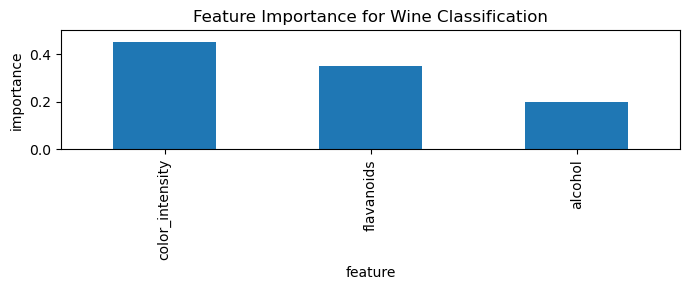

,feature,importance
0,color_intensity,0.45
1,flavanoids,0.35
2,alcohol,0.20


In [4]:
feature_importance = pd.DataFrame([
    {"feature": "color_intensity", "importance": 0.45},
    {"feature": "flavanoids", "importance": 0.35},
    {"feature": "alcohol", "importance": 0.20},
])

assert abs(feature_importance["importance"].sum() - 1.0) < 1e-9

ax = feature_importance.plot(
    kind="bar",
    x="feature",
    y="importance",
    legend=False,
    figsize=(7, 3),
    title="Feature Importance for Wine Classification",
)
ax.set_ylabel("importance")
ax.set_ylim(0, 0.5)
plt.tight_layout()
plt.show()

feature_importance

## 5. FastAPI/Gradio에 연결할 서비스 함수

웹 서비스에서는 화면이 직접 모델을 다루지 않고, 서비스 함수가 중간에서 입력 검증과 예측 호출을 담당합니다.

아래 `dashboard_payload` 함수는 대시보드에서 필요한 원본 데이터, 요약 데이터, 중요도, 예측 결과를 한 번에 반환합니다.
FastAPI에서는 이 딕셔너리를 JSON으로 반환할 수 있고, Gradio에서는 각각의 출력 컴포넌트로 나누어 표시할 수 있습니다.

In [5]:
def dashboard_payload(alcohol: float, color_intensity: float, flavanoids: float) -> dict:
    prediction = predict_wine_class(alcohol, color_intensity, flavanoids)
    return {
        "rows": wine.to_dict(orient="records"),
        "summary": class_summary.to_dict(orient="records"),
        "feature_importance": feature_importance.to_dict(orient="records"),
        "prediction": prediction,
    }

payload = dashboard_payload(13.5, 6.5, 1.2)

assert payload["prediction"]["prediction"] == "class_2"
assert len(payload["summary"]) == wine["class_name"].nunique()
payload["prediction"]

{'input': {'alcohol': 13.5, 'color_intensity': 6.5, 'flavanoids': 1.2},
 'prediction': 'class_2',
 'reason': '색 농도가 높아 class_2로 분류했습니다.'}

## 정리

11주차의 핵심은 모델 자체보다 **모델을 사용자가 이해할 수 있는 서비스 화면으로 연결하는 구조**입니다.

- 데이터 조회: 원본 데이터와 요약표 제공
- 모델 설명: 피처 중요도 제공
- 예측 기능: 입력값 검증 후 예측 결과와 이유 반환
- 서비스 연결: FastAPI 또는 Gradio가 호출할 수 있는 함수 형태로 정리